# Indian Railway Delay Prediction

## Classification — Review 1

### Objective

The objective of this notebook is to predict whether a train journey is delayed using the `is_delayed` target variable.

The five Classification Part-A algorithms required for Review 1 are:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Classifier (SVC)

The models are evaluated using Accuracy, Precision, Recall, Weighted F1-Score, Confusion Matrix and ROC-AUC.

In [4]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load Dataset

The training and test datasets are stored in the project's `data` folder.

The paths are relative to this notebook because the notebook is inside the `notebooks` folder.

In [9]:
TRAIN_FILE = "ir_train_siddu.csv"
TEST_FILE = "ir_test_siddu.csv"

train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)

print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape :", test_df.shape)

display(train_df.head())

Training Dataset Shape: (1500000, 45)
Testing Dataset Shape : (375000, 42)


,journey_id,train_number,train_type,departure_date,year,month,day_of_week,departure_hour,is_weekend,is_night_departure,...,is_rake_shared,maintenance_score,seat_utilisation_pct,is_overloaded,late_incoming_rake,is_special_train,route_historical_ontime_pct,primary_delay_cause,delay_minutes,is_delayed
0,IR01717809,12536,Superfast Express,2023-09-18,2023,9,0,7,0,0,...,1,5.5,88.8,0,0,0,67.8,Flooding / Waterlogging,110,1
1,IR00931776,12806,Superfast Express,2020-04-09,2020,4,3,8,0,0,...,1,6.6,83.6,0,0,0,57.0,On Time,3,0
2,IR00096904,22416,Vande Bharat Express,2024-12-13,2024,12,4,18,0,0,...,0,4.1,81.6,0,0,0,81.8,On Time,5,0
3,IR00047736,12250,Garib Rath Express,2018-11-29,2018,11,3,18,0,0,...,0,5.5,82.1,0,1,0,52.3,Track Congestion,135,1
4,IR00726037,74588,DEMU/MEMU,2020-06-18,2020,6,3,5,0,0,...,1,8.0,58.3,0,1,0,64.3,Track Congestion,154,1


## 2. Dataset Audit

The dataset is checked for:

- Shape
- Data types
- Missing values
- Duplicate records
- Target distribution

This helps understand the quality and structure of the data before preprocessing.

In [10]:
print("Training Dataset Information")
print("=" * 50)

print("Rows:", train_df.shape[0])
print("Columns:", train_df.shape[1])

print("\nData Types:")
display(train_df.dtypes.to_frame("Data Type"))

print("\nMissing Values:")
missing_values = train_df.isnull().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0].to_frame("Missing Count"))

print("\nDuplicate Rows:", train_df.duplicated().sum())

print("\nTarget Distribution:")
display(train_df["is_delayed"].value_counts())

print("\nTarget Percentage:")
display(
    train_df["is_delayed"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame("Percentage")
)

Training Dataset Information
Rows: 1500000
Columns: 45

Data Types:


,Data Type
journey_id,object
train_number,int64
train_type,object
departure_date,object
year,int64
month,int64
day_of_week,int64
departure_hour,int64
is_weekend,int64
is_night_departure,int64



Missing Values:


,Missing Count



Duplicate Rows: 0

Target Distribution:


is_delayed
1    1078329
0     421671
Name: count, dtype: int64


Target Percentage:


,Percentage
is_delayed,
1,71.89
0,28.11


## 3. Target Distribution

The target variable is `is_delayed`.

- `0` represents a train that is not delayed.
- `1` represents a delayed train.

The distribution is visualized to check whether the classification problem is balanced or imbalanced.

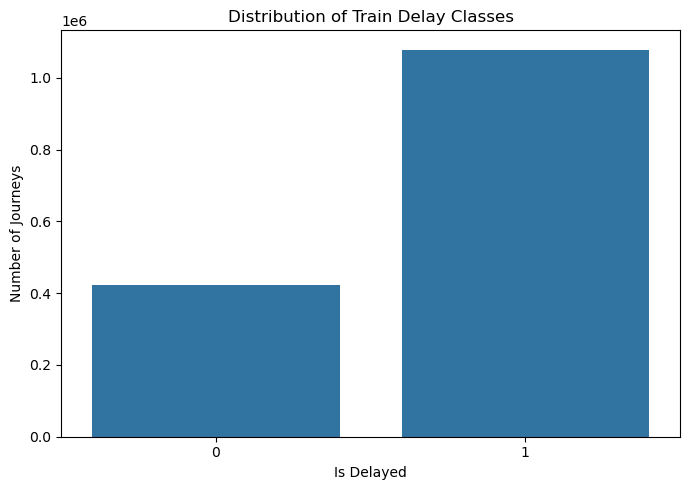

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=train_df,
    x="is_delayed"
)

plt.title("Distribution of Train Delay Classes")
plt.xlabel("Is Delayed")
plt.ylabel("Number of Journeys")

plt.tight_layout()
plt.show()

### Observation

The target distribution shows the number of delayed and non-delayed journeys. 
If the two classes are not equally represented, weighted evaluation metrics are useful for fair model comparison.

## 4. Numerical Feature Distributions

Histograms are used to understand the distributions of numerical variables and identify skewness or unusual values.

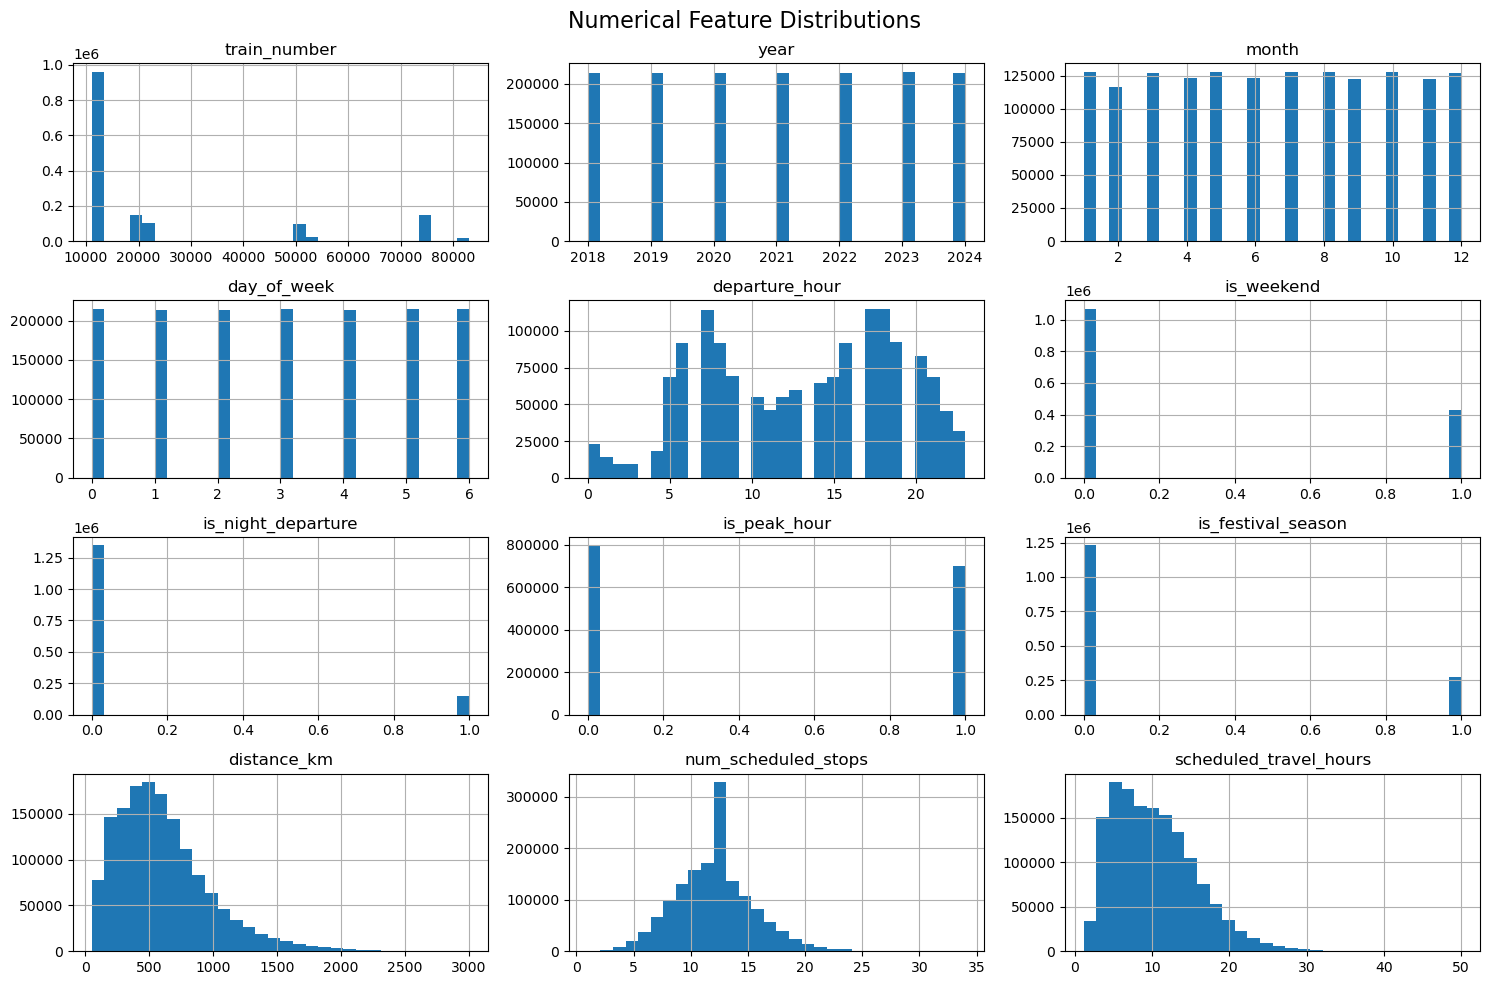

In [12]:
numeric_columns = train_df.select_dtypes(
    include=np.number
).columns.tolist()

# Remove target and leakage variables
numeric_plot_columns = [
    col for col in numeric_columns
    if col not in ["is_delayed", "delay_minutes"]
]

# Plot maximum 12 numerical features
plot_columns = numeric_plot_columns[:12]

train_df[plot_columns].hist(
    figsize=(15, 10),
    bins=30
)

plt.suptitle(
    "Numerical Feature Distributions",
    fontsize=16
)

plt.tight_layout()
plt.show()

## 5. Correlation Heatmap

The correlation matrix helps identify relationships between numerical variables.

Strongly correlated variables may contain similar information and can affect some classification algorithms.

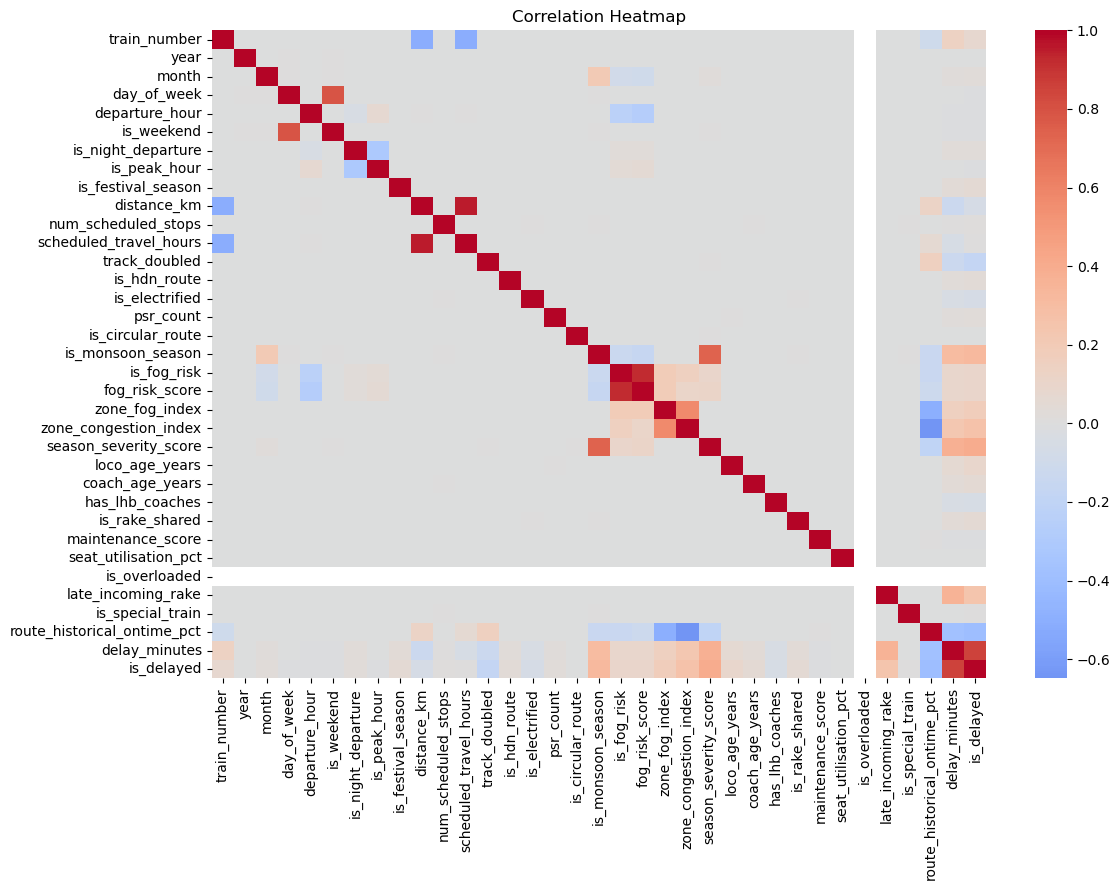

In [13]:
corr_columns = train_df.select_dtypes(
    include=np.number
).columns.tolist()

correlation_matrix = train_df[corr_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows the relationships between numerical variables. 
It can help identify variables that contain similar information and may be useful during feature selection.

## 6. Data Cleaning and Feature Preparation

The classification target is:

`is_delayed`

The following columns are removed from the feature set:

- `is_delayed` — target variable
- `delay_minutes` — directly represents the amount of delay and would cause target leakage
- `primary_delay_cause` — describes the cause of an observed delay and can leak information about the outcome

Numerical missing values are handled using median imputation.

Categorical missing values are handled using the most frequent category.

Categorical variables are converted using One-Hot Encoding.

Numerical variables are standardized because KNN and SVC are distance/margin-based algorithms.

In [14]:
TARGET = "is_delayed"

LEAKAGE_COLUMNS = [
    "delay_minutes",
    "primary_delay_cause"
]

# Create feature matrix
X = train_df.drop(
    columns=[TARGET] + [
        col for col in LEAKAGE_COLUMNS
        if col in train_df.columns
    ]
)

# Target
y = train_df[TARGET].astype(int)

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Values:")
print(y.value_counts())

Feature Matrix Shape: (1500000, 42)
Target Shape: (1500000,)

Target Values:
is_delayed
1    1078329
0     421671
Name: count, dtype: int64


## 7. Train-Validation Split

An 80:20 split is used.

Stratification is applied so that the proportion of delayed and non-delayed journeys remains similar in both training and validation data.

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Validation Data:", X_val.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation Target Distribution:")
print(y_val.value_counts(normalize=True))

Training Data: (1200000, 42)
Validation Data: (300000, 42)

Training Target Distribution:
is_delayed
1    0.718886
0    0.281114
Name: proportion, dtype: float64

Validation Target Distribution:
is_delayed
1    0.718887
0    0.281113
Name: proportion, dtype: float64


In [16]:
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Number of numerical features: 33
Number of categorical features: 9


In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True,
            dtype=np.float32,
            min_frequency=100
        ))
    ]
)

# Combined preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ],
    sparse_threshold=1.0
)

print("Memory-efficient preprocessing pipeline created successfully.")

Memory-efficient preprocessing pipeline created successfully.


# 8. Logistic Regression

Logistic Regression is used as the baseline classification model.

It predicts the probability that an observation belongs to the delayed class.

In [31]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            solver="saga",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

start_time = time.time()

logistic_model.fit(X_train, y_train)

logistic_time = time.time() - start_time

# Predictions
logistic_pred = logistic_model.predict(X_val)
logistic_prob = logistic_model.predict_proba(X_val)[:, 1]

# Metrics
logistic_accuracy = accuracy_score(y_val, logistic_pred)
logistic_precision = precision_score(
    y_val, logistic_pred, zero_division=0
)
logistic_recall = recall_score(
    y_val, logistic_pred, zero_division=0
)
logistic_f1 = f1_score(
    y_val, logistic_pred, average="weighted", zero_division=0
)
logistic_auc = roc_auc_score(
    y_val, logistic_prob
)

# Results
print("Logistic Regression trained successfully.")
print("Training time:", round(logistic_time, 2), "seconds")

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        logistic_pred,
        zero_division=0
    )
)

print("\nPerformance Metrics:")
print("Accuracy    :", round(logistic_accuracy, 4))
print("Precision   :", round(logistic_precision, 4))
print("Recall      :", round(logistic_recall, 4))
print("Weighted F1 :", round(logistic_f1, 4))
print("ROC-AUC     :", round(logistic_auc, 4))

Logistic Regression trained successfully.
Training time: 762.34 seconds

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.83      0.75     84334
           1       0.93      0.86      0.89    215666

    accuracy                           0.85    300000
   macro avg       0.81      0.84      0.82    300000
weighted avg       0.86      0.85      0.85    300000


Performance Metrics:
Accuracy    : 0.8474
Precision   : 0.9261
Recall      : 0.8561
Weighted F1 : 0.8512
ROC-AUC     : 0.9233


# 9. K-Nearest Neighbors

KNN classifies a sample according to the classes of its nearest neighbours.

Feature scaling is particularly important because KNN uses distance calculations.

In [32]:
from sklearn.model_selection import train_test_split

# KNN is computationally expensive on the complete dataset.
# Therefore, a fixed stratified sample is used for KNN.

KNN_TRAIN_SIZE = 50000
KNN_VAL_SIZE = 10000

# Create a stratified training sample
X_knn_train, _, y_knn_train, _ = train_test_split(
    X_train,
    y_train,
    train_size=KNN_TRAIN_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE
)

# Create a stratified validation sample
X_knn_val, _, y_knn_val, _ = train_test_split(
    X_val,
    y_val,
    train_size=KNN_VAL_SIZE,
    stratify=y_val,
    random_state=RANDOM_STATE
)

print("KNN training samples:", len(X_knn_train))
print("KNN validation samples:", len(X_knn_val))

# KNN pipeline
knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(
            n_neighbors=5,
            n_jobs=-1
        ))
    ]
)

start_time = time.time()

knn_model.fit(X_knn_train, y_knn_train)

knn_time = time.time() - start_time

# Predictions
knn_pred = knn_model.predict(X_knn_val)
knn_prob = knn_model.predict_proba(X_knn_val)[:, 1]

# Metrics
knn_accuracy = accuracy_score(y_knn_val, knn_pred)

knn_precision = precision_score(
    y_knn_val,
    knn_pred,
    zero_division=0
)

knn_recall = recall_score(
    y_knn_val,
    knn_pred,
    zero_division=0
)

knn_f1 = f1_score(
    y_knn_val,
    knn_pred,
    average="weighted",
    zero_division=0
)

knn_auc = roc_auc_score(
    y_knn_val,
    knn_prob
)

# Results
print("\nKNN trained successfully.")
print("Training time:", round(knn_time, 2), "seconds")

print("\nClassification Report:")
print(
    classification_report(
        y_knn_val,
        knn_pred,
        zero_division=0
    )
)

print("\nPerformance Metrics:")
print("Accuracy      :", round(knn_accuracy, 4))
print("Precision     :", round(knn_precision, 4))
print("Recall        :", round(knn_recall, 4))
print("Weighted F1   :", round(knn_f1, 4))
print("ROC-AUC       :", round(knn_auc, 4))

KNN training samples: 50000
KNN validation samples: 10000

KNN trained successfully.
Training time: 3.05 seconds

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.59      0.62      2811
           1       0.85      0.88      0.86      7189

    accuracy                           0.80     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.79      0.80      0.80     10000


Performance Metrics:
Accuracy      : 0.7988
Precision     : 0.8466
Recall        : 0.8795
Weighted F1   : 0.7954
ROC-AUC       : 0.8315


# 10. Gaussian Naive Bayes

Gaussian Naive Bayes applies Bayes' theorem while assuming conditional independence between features.

It is computationally simple and provides a useful probabilistic baseline.

In [34]:
from sklearn.decomposition import TruncatedSVD

# GaussianNB requires dense input.
# TruncatedSVD converts the large sparse feature matrix
# into a small dense feature representation.

GNB_TRAIN_SIZE = 50000
GNB_VAL_SIZE = 10000

# Create a stratified training sample
X_gnb_train, _, y_gnb_train, _ = train_test_split(
    X_train,
    y_train,
    train_size=GNB_TRAIN_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE
)

# Create a stratified validation sample
X_gnb_val, _, y_gnb_val, _ = train_test_split(
    X_val,
    y_val,
    train_size=GNB_VAL_SIZE,
    stratify=y_val,
    random_state=RANDOM_STATE
)

print("GNB training samples:", len(X_gnb_train))
print("GNB validation samples:", len(X_gnb_val))


# GaussianNB pipeline
gnb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("svd", TruncatedSVD(
            n_components=50,
            random_state=RANDOM_STATE
        )),
        ("classifier", GaussianNB())
    ]
)

start_time = time.time()

gnb_model.fit(
    X_gnb_train,
    y_gnb_train
)

gnb_time = time.time() - start_time

# Predictions
gnb_pred = gnb_model.predict(X_gnb_val)
gnb_prob = gnb_model.predict_proba(X_gnb_val)[:, 1]

# Metrics
gnb_accuracy = accuracy_score(
    y_gnb_val,
    gnb_pred
)

gnb_precision = precision_score(
    y_gnb_val,
    gnb_pred,
    zero_division=0
)

gnb_recall = recall_score(
    y_gnb_val,
    gnb_pred,
    zero_division=0
)

gnb_f1 = f1_score(
    y_gnb_val,
    gnb_pred,
    average="weighted",
    zero_division=0
)

gnb_auc = roc_auc_score(
    y_gnb_val,
    gnb_prob
)

# Results
print("\nGaussian Naive Bayes trained successfully.")
print("Training time:", round(gnb_time, 2), "seconds")

print("\nClassification Report:")
print(
    classification_report(
        y_gnb_val,
        gnb_pred,
        zero_division=0
    )
)

print("\nPerformance Metrics:")
print("Accuracy      :", round(gnb_accuracy, 4))
print("Precision     :", round(gnb_precision, 4))
print("Recall        :", round(gnb_recall, 4))
print("Weighted F1   :", round(gnb_f1, 4))
print("ROC-AUC       :", round(gnb_auc, 4))

GNB training samples: 50000
GNB validation samples: 10000

Gaussian Naive Bayes trained successfully.
Training time: 6.78 seconds

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.67      0.65      2811
           1       0.87      0.85      0.86      7189

    accuracy                           0.80     10000
   macro avg       0.75      0.76      0.76     10000
weighted avg       0.80      0.80      0.80     10000


Performance Metrics:
Accuracy      : 0.7987
Precision     : 0.8688
Recall        : 0.8481
Weighted F1   : 0.8005
ROC-AUC       : 0.8598


# 11. Decision Tree Classifier

A Decision Tree recursively splits the dataset based on feature values.

Decision Trees can model non-linear relationships and are easy to interpret.

In [35]:
DT_TRAIN_SIZE = 100000
DT_VAL_SIZE = 20000

# Create a stratified training sample
X_dt_train, _, y_dt_train, _ = train_test_split(
    X_train,
    y_train,
    train_size=DT_TRAIN_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE
)

# Create a stratified validation sample
X_dt_val, _, y_dt_val, _ = train_test_split(
    X_val,
    y_val,
    train_size=DT_VAL_SIZE,
    stratify=y_val,
    random_state=RANDOM_STATE
)

print("Decision Tree training samples:", len(X_dt_train))
print("Decision Tree validation samples:", len(X_dt_val))


# Decision Tree pipeline
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=8,
            random_state=RANDOM_STATE
        ))
    ]
)

start_time = time.time()

decision_tree_model.fit(
    X_dt_train,
    y_dt_train
)

decision_tree_time = time.time() - start_time

# Predictions
decision_tree_pred = decision_tree_model.predict(X_dt_val)

decision_tree_prob = decision_tree_model.predict_proba(
    X_dt_val
)[:, 1]

# Metrics
decision_tree_accuracy = accuracy_score(
    y_dt_val,
    decision_tree_pred
)

decision_tree_precision = precision_score(
    y_dt_val,
    decision_tree_pred,
    zero_division=0
)

decision_tree_recall = recall_score(
    y_dt_val,
    decision_tree_pred,
    zero_division=0
)

decision_tree_f1 = f1_score(
    y_dt_val,
    decision_tree_pred,
    average="weighted",
    zero_division=0
)

decision_tree_auc = roc_auc_score(
    y_dt_val,
    decision_tree_prob
)

# Results
print("\nDecision Tree trained successfully.")
print("Training time:", round(decision_tree_time, 2), "seconds")

print("\nClassification Report:")
print(
    classification_report(
        y_dt_val,
        decision_tree_pred,
        zero_division=0
    )
)

print("\nPerformance Metrics:")
print("Accuracy      :", round(decision_tree_accuracy, 4))
print("Precision     :", round(decision_tree_precision, 4))
print("Recall        :", round(decision_tree_recall, 4))
print("Weighted F1   :", round(decision_tree_f1, 4))
print("ROC-AUC       :", round(decision_tree_auc, 4))

Decision Tree training samples: 100000
Decision Tree validation samples: 20000

Decision Tree trained successfully.
Training time: 19.76 seconds

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.64      0.68      5622
           1       0.86      0.91      0.89     14378

    accuracy                           0.83     20000
   macro avg       0.80      0.77      0.78     20000
weighted avg       0.83      0.83      0.83     20000


Performance Metrics:
Accuracy      : 0.8311
Precision     : 0.8644
Recall        : 0.9074
Weighted F1   : 0.8274
ROC-AUC       : 0.8881


# 12. Support Vector Classifier

Support Vector Classifier attempts to find a decision boundary that maximizes the margin between classes.

Feature scaling is important for SVC.

`probability=True` is enabled so that predicted probabilities can be used to calculate ROC-AUC.

In [39]:
# ============================================================
# 12. Support Vector Classifier (SVC)
# ============================================================

SVC_TRAIN_SIZE = 30000
SVC_VAL_SIZE = 5000

# Create a stratified training sample
X_svc_train, _, y_svc_train, _ = train_test_split(
    X_train,
    y_train,
    train_size=SVC_TRAIN_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE
)

# Create a stratified validation sample
X_svc_val, _, y_svc_val, _ = train_test_split(
    X_val,
    y_val,
    train_size=SVC_VAL_SIZE,
    stratify=y_val,
    random_state=RANDOM_STATE
)

print("SVC training samples:", len(X_svc_train))
print("SVC validation samples:", len(X_svc_val))


# SVC pipeline
svc_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("svd", TruncatedSVD(
            n_components=50,
            random_state=RANDOM_STATE
        )),
        ("classifier", SVC(
            C=1.0,
            kernel="rbf",
            probability=True,
            random_state=RANDOM_STATE
        ))
    ]
)

start_time = time.time()

svc_model.fit(
    X_svc_train,
    y_svc_train
)

svc_time = time.time() - start_time

# Predictions
svc_pred = svc_model.predict(X_svc_val)

svc_prob = svc_model.predict_proba(
    X_svc_val
)[:, 1]

# Metrics
svc_accuracy = accuracy_score(
    y_svc_val,
    svc_pred
)

svc_precision = precision_score(
    y_svc_val,
    svc_pred,
    zero_division=0
)

svc_recall = recall_score(
    y_svc_val,
    svc_pred,
    zero_division=0
)

svc_f1 = f1_score(
    y_svc_val,
    svc_pred,
    average="weighted",
    zero_division=0
)

svc_auc = roc_auc_score(
    y_svc_val,
    svc_prob
)

# Results
print("\nSVC trained successfully.")
print("Training time:", round(svc_time, 2), "seconds")

print("\nClassification Report:")
print(
    classification_report(
        y_svc_val,
        svc_pred,
        zero_division=0
    )
)

print("\nPerformance Metrics:")
print("Accuracy      :", round(svc_accuracy, 4))
print("Precision     :", round(svc_precision, 4))
print("Recall        :", round(svc_recall, 4))
print("Weighted F1   :", round(svc_f1, 4))
print("ROC-AUC       :", round(svc_auc, 4))

SVC training samples: 30000
SVC validation samples: 5000

SVC trained successfully.
Training time: 491.42 seconds

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.66      0.70      1406
           1       0.87      0.91      0.89      3594

    accuracy                           0.84      5000
   macro avg       0.81      0.79      0.80      5000
weighted avg       0.84      0.84      0.84      5000


Performance Metrics:
Accuracy      : 0.8416
Precision     : 0.8732
Recall        : 0.9121
Weighted F1   : 0.8385
ROC-AUC       : 0.8982


In [42]:
# Fix SVC validation data

SVC_VAL_SIZE = 2000

X_svc_val, _, y_svc_val, _ = train_test_split(
    X_val,
    y_val,
    train_size=SVC_VAL_SIZE,
    stratify=y_val,
    random_state=RANDOM_STATE
)

svc_pred = svc_model.predict(X_svc_val)

svc_score = svc_model.decision_function(X_svc_val)

print("SVC validation samples:", len(y_svc_val))
print("SVC predictions:", len(svc_pred))
print("SVC scores:", len(svc_score))

SVC validation samples: 2000
SVC predictions: 2000
SVC scores: 2000


# 13. Model Comparison

The five classifiers are compared using:

- Accuracy
- Precision
- Recall
- Weighted F1-Score
- ROC-AUC

All models are evaluated on the same validation set.

In [43]:
# ============================================================
# Classification Model Comparison
# ============================================================

models = {
    "Logistic Regression": (
        y_val,
        logistic_pred,
        logistic_prob
    ),

    "KNN": (
        y_knn_val,
        knn_pred,
        knn_prob
    ),

    "Gaussian Naive Bayes": (
        y_gnb_val,
        gnb_pred,
        gnb_prob
    ),

    "Decision Tree": (
        y_dt_val,
        decision_tree_pred,
        decision_tree_prob
    ),

    "SVC": (
        y_svc_val,
        svc_pred,
        svc_score
    )
}

results = []

for name, (y_true, predictions, scores) in models.items():

    results.append({
        "Model": name,

        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),

        "Precision": precision_score(
            y_true,
            predictions,
            average="weighted",
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            predictions,
            average="weighted",
            zero_division=0
        ),

        "F1-Score": f1_score(
            y_true,
            predictions,
            average="weighted",
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            scores
        )
    })

classification_results = pd.DataFrame(results)

classification_results = classification_results.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

display(
    classification_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8474,0.8602,0.8474,0.8512,0.9233
1,SVC,0.8400,0.8360,0.8400,0.8371,0.9020
2,Decision Tree,0.8311,0.8262,0.8311,0.8274,0.8881
3,Gaussian Naive Bayes,0.7987,0.8027,0.7987,0.8005,0.8598
4,KNN,0.7988,0.7935,0.7988,0.7954,0.8315


In [44]:
os.makedirs("../results", exist_ok=True)

classification_results.to_csv(
    "../results/classification_part_a_results.csv",
    index=False
)

print("Results saved successfully.")
print("../results/classification_part_a_results.csv")

Results saved successfully.
../results/classification_part_a_results.csv


# 14. Confusion Matrices

Confusion matrices are generated for all five classifiers.

They show:

- True Negative
- False Positive
- False Negative
- True Positive

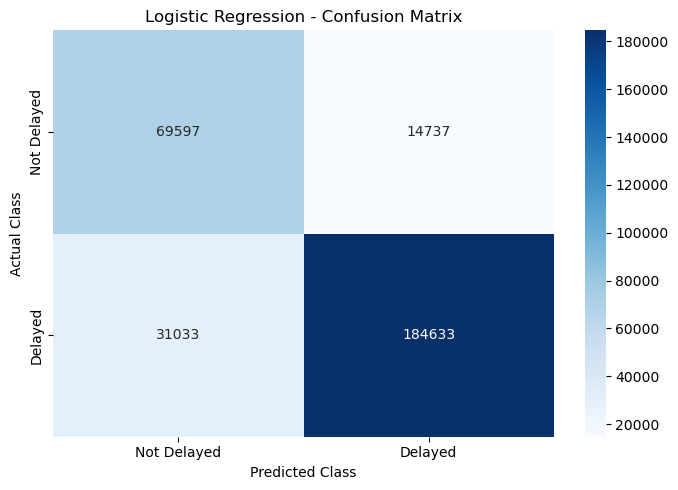

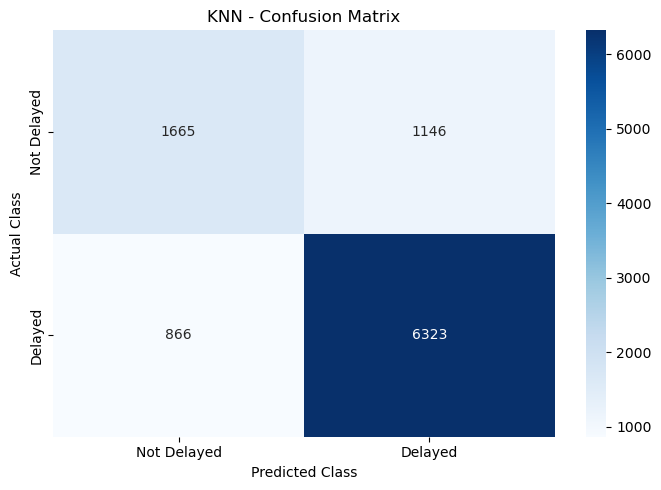

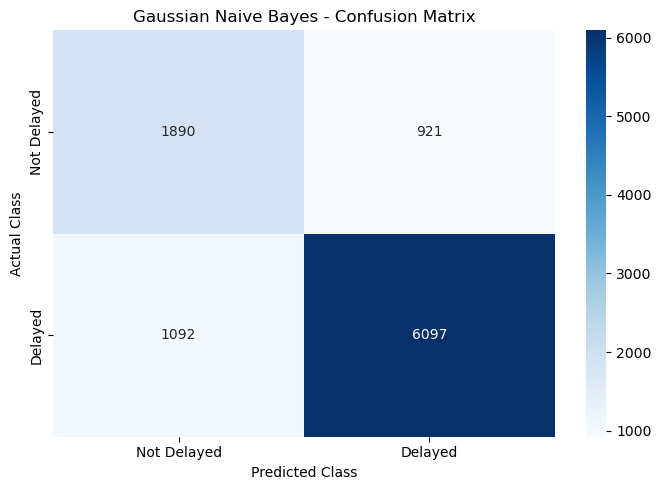

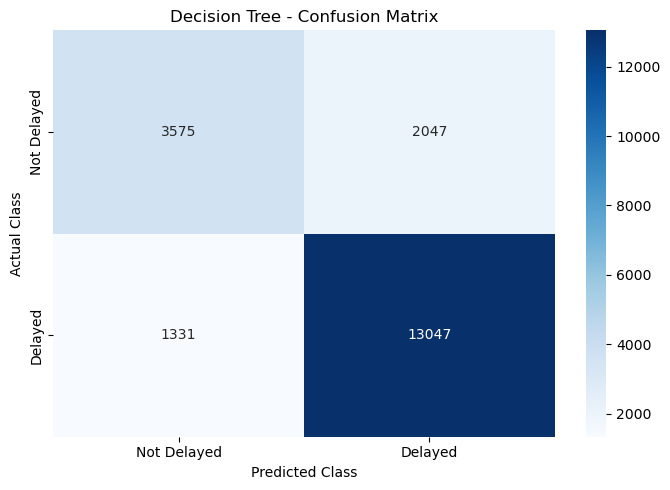

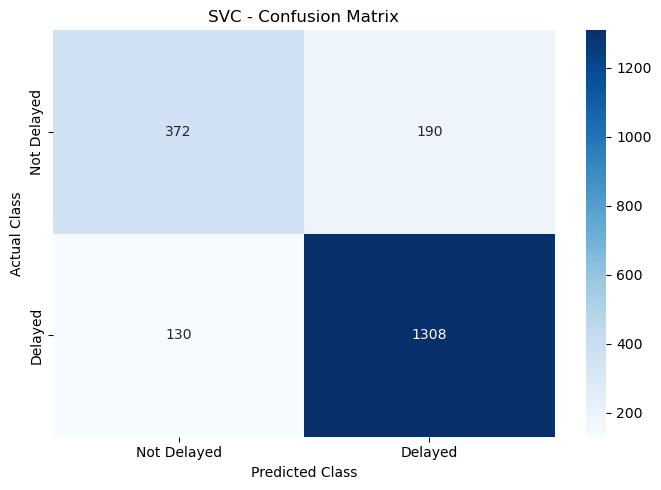

In [47]:
for name, (y_true, predictions, _) in models.items():

    cm = confusion_matrix(
        y_true,
        predictions
    )

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Not Delayed", "Delayed"],
        yticklabels=["Not Delayed", "Delayed"]
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.tight_layout()
    plt.show()

# 15. ROC Curve Comparison

The ROC curve shows the relationship between the True Positive Rate and False Positive Rate.

The Area Under the Curve (ROC-AUC) is used to compare the classification models.

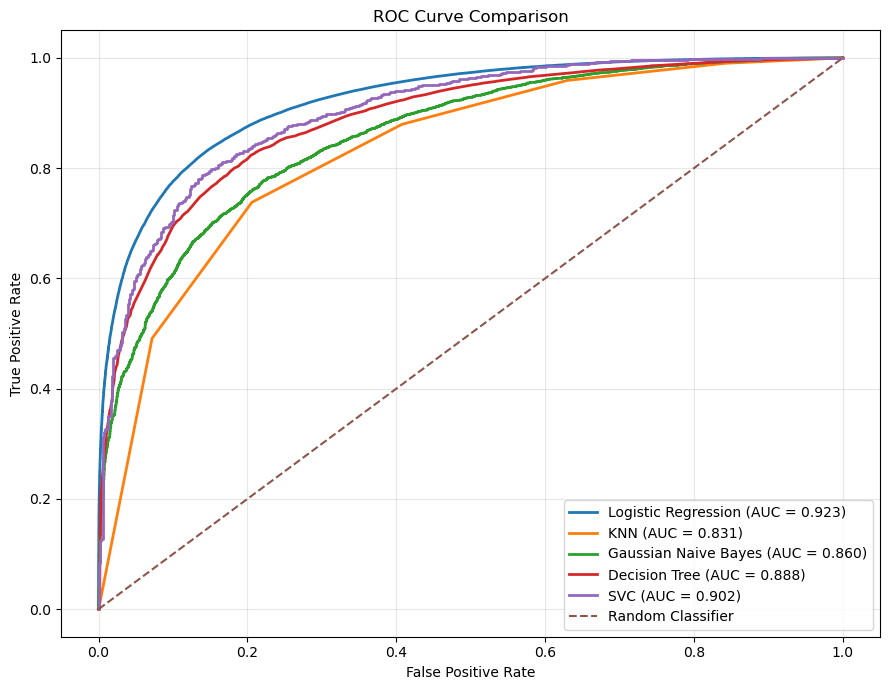

In [49]:
plt.figure(figsize=(9, 7))

for name, (y_true, _, scores) in models.items():

    fpr, tpr, _ = roc_curve(
        y_true,
        scores
    )

    auc_score = roc_auc_score(
        y_true,
        scores
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 16. Classification Metrics Comparison

The following graph provides a visual comparison of Accuracy, Precision, Recall, F1-Score and ROC-AUC for all five models.

<Figure size 1300x700 with 0 Axes>

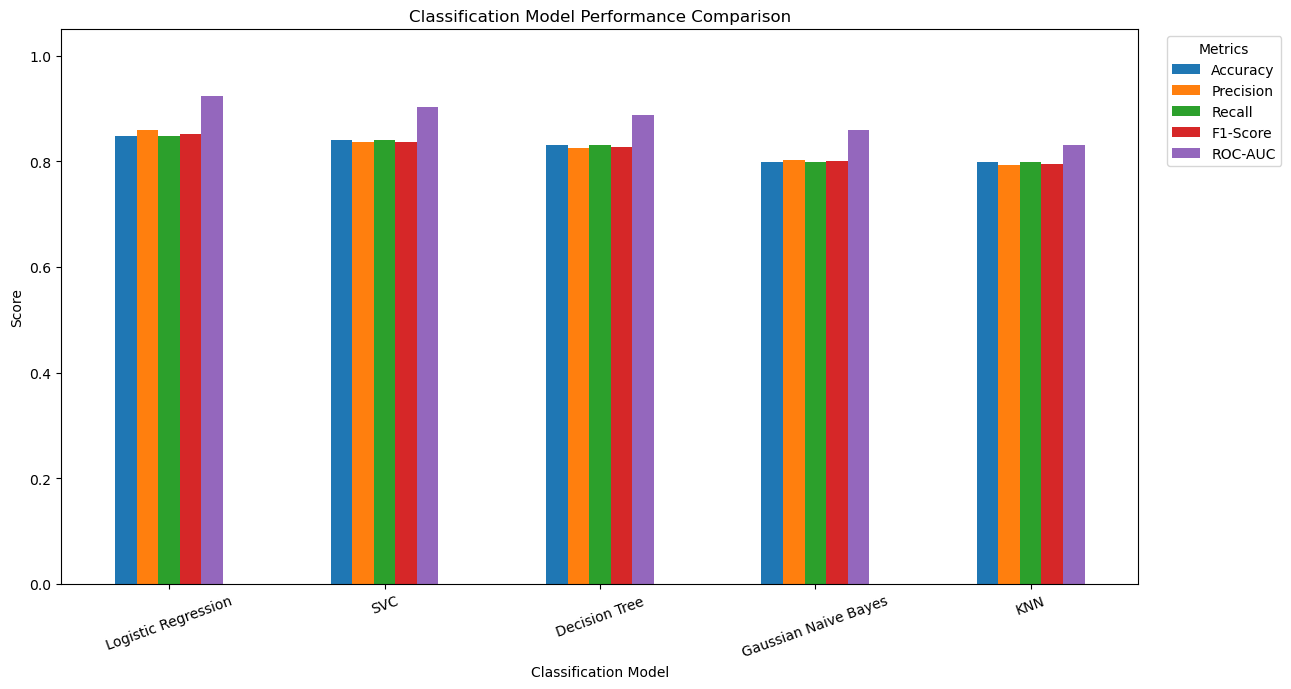

In [50]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

plot_df = classification_results.set_index("Model")[metrics]

plt.figure(figsize=(13, 7))

plot_df.plot(
    kind="bar",
    figsize=(13, 7)
)

plt.title("Classification Model Performance Comparison")
plt.xlabel("Classification Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.xticks(rotation=20)

plt.legend(
    title="Metrics",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# 17. Best Classification Model

The model with the highest weighted F1-score is selected as the preliminary best model for Review 1.

Weighted F1-score is useful because it considers both precision and recall while accounting for the number of observations in each class.

In [51]:
best_model_name = classification_results.iloc[0]["Model"]

best_model = models[best_model_name][0]
best_predictions = models[best_model_name][1]

print("Best Classification Model:")
print(best_model_name)

print("\nDetailed Classification Report:")
print(
    classification_report(
        y_val,
        best_predictions,
        zero_division=0
    )
)

Best Classification Model:
Logistic Regression

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.83      0.75     84334
           1       0.93      0.86      0.89    215666

    accuracy                           0.85    300000
   macro avg       0.81      0.84      0.82    300000
weighted avg       0.86      0.85      0.85    300000



# 18. Conclusion

Five Classification Part-A algorithms were implemented:

1. Logistic Regression
2. K-Nearest Neighbors
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Classifier

The models were evaluated using Accuracy, Precision, Recall, Weighted F1-Score, Confusion Matrix and ROC-AUC.

The comparison table provides a consistent basis for selecting the best-performing classifier.

For Review 2, the five Classification Part-B algorithms will be added and combined with these five models to create the required ten-algorithm classification comparison.